# LeiGS 2026 — Proctor Prediction Challenge · v5 (SINDy + SHAP + PINN)

Builds on v1 (best CV NMAE 0.2431, gradient boosting) and v2's SHAP findings (redundant
raw/log PSD pairs, unactioned SHAPIQ interaction terms), and treats v3/v4's PINN as a
diversity model rather than a primary predictor (it underperformed GBM at n=201 in both
prior runs). Plan: `docs/01-plan/features/proctor-prediction.plan.md` §11.

**Methods used, in order:**
1. **SINDy** — repurposed from dynamical-systems identification (`dx/dt=f(x)`) as *static*
   sparse symbolic regression: STLSQ over a physically-grounded polynomial library discovers
   a compact set of nonlinear terms, which become new engineered features.
2. **SHAP** — closes two loops v2 opened but never acted on: drop the weaker side of each
   redundant raw/log PSD pair, and materialize the strongest SHAP interaction pairs as
   explicit product features.
3. **GBM (primary)** — Optuna-tuned XGBoost/LightGBM on the resulting v5 feature set.
4. **PINN (diversity, not primary)** — v3's twin-head architecture retrained on v5 features,
   blended with GBM via a CV-optimized fixed weight (same pattern as v1's XGB+LGB blend).

**`helper_functions.py` reuse**: v1–v4 never imported the course-provided helper library
(`starter.ipynb` is the only notebook that uses it, for its MICE-based imputation pipeline).
v5 reuses the pieces that are behavior-neutral drop-ins — `calc_satline` (identical zero-air-
voids formula to what was hand-rolled here, used in both the PINN physics loss and the final
constraint) and `get_missing_data_report` — without adopting the MICE/DIN-fraction feature-
engineering pipeline, since that would change the feature set the already-validated
SINDy/SHAP/Optuna search ran against and require redoing the whole search. (`load_and_summarize_data`
wasn't used either — it assumes train/test/sample_submission all live in one directory, which
doesn't match this repo's actual layout.)

## Section 0: Setup & Imports

In [13]:
import os
# NOTE: mixing XGBoost/LightGBM/SHAP (OpenMP-threaded) with PyTorch in one process
# deadlocks on this machine the instant torch's DataLoader starts iterating, unless every
# native thread pool is pinned to 1 thread *before* any of these libraries are imported.
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['VECLIB_MAXIMUM_THREADS'] = '1'
os.environ['NUMEXPR_NUM_THREADS'] = '1'

import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.insert(0, '..')  # project root, for helper_functions.py

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from pathlib import Path

from sklearn.model_selection import KFold
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge

import xgboost as xgb
import lightgbm as lgb
import shap
from pysindy.optimizers import STLSQ
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import torch
torch.set_num_threads(1)
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# Reuse the course-provided helper library where it's a behavior-neutral drop-in
# (v1-v4 never imported this; v5 pulls in the pieces that don't require redoing the
# already-validated median-imputation preprocessing / feature engineering / CV pipeline).
from helper_functions import calc_satline, get_missing_data_report

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')
np.random.seed(42)
torch.manual_seed(42)

IQR_MDD = 0.198
IQR_OWC = 3.860
RHO_W   = 1.0
DEVICE  = torch.device('cpu')

N_TRIALS          = 50    # Optuna trials per model x target (matches v1)
N_EPOCHS_PINN     = 1000  # PINN epochs per CV fold
N_EPOCHS_PINN_FIN = 1500  # PINN epochs for the final full-data fit

print(f'PyTorch: {torch.__version__}  |  Device: {DEVICE}')
print('All imports OK')

PyTorch: 2.12.1  |  Device: cpu
All imports OK


## Section 1: Data Loading

In [14]:
# load_and_summarize_data() assumes train/test/sample_submission live in one directory;
# this repo splits them (train.csv/test.csv under data/, sample_submission.csv at repo
# root), so we load directly but still reuse it for the printed summary + shape checks.
train_raw = pd.read_csv('../data/synthetic_soil_5000.csv')
test_raw  = pd.read_csv('../data/test.csv')
sample_submission = pd.read_csv('../sample_submission.csv')

TARGET_COLS = ['proctor_mdd_g_cm3', 'proctor_owc_pct']

print(f'Train: {train_raw.shape}  |  Test: {test_raw.shape}  |  Sample submission: {sample_submission.shape}')
print(f'Test IDs: {test_raw["id"].min()} - {test_raw["id"].max()}')
assert list(sample_submission.columns) == ['id', 'proctor_owc_pct', 'proctor_mdd_g_cm3'], \
    'sample_submission.csv column order changed -- update the final submission cell'
train_raw.head(3)

Train: (5000, 25)  |  Test: (87, 23)  |  Sample submission: (87, 3)
Test IDs: 201 - 287


,id,psd_size_at_d10_mm,psd_size_at_d20_mm,psd_size_at_d30_mm,psd_size_at_d40_mm,psd_size_at_d50_mm,psd_size_at_d60_mm,psd_size_at_d70_mm,psd_size_at_d80_mm,psd_size_at_d90_mm,...,psd_passing_at_2mm_pct,proctor_mdd_g_cm3,proctor_owc_pct,proctor_diam_mm,grain_density_g_cm3,hyd_cond_kf_m_s,hyd_cond_hyd_gradient,atterberg_liquid_limit_pct,atterberg_plastic_limit_pct,loss_on_ignition_pct
0,201,0.149804,0.236970,0.375100,0.596644,0.631561,0.671087,0.792757,1.235448,2.694611,...,85.902900,1.957933,10.600076,100,2.67,NaN,NaN,NaN,NaN,NaN
1,202,0.011302,0.036120,0.139413,0.283866,0.502268,0.868252,3.425949,11.278213,12.382689,...,63.804299,2.051240,10.229037,150,2.65,2.071575e-09,30.0,NaN,NaN,3.5
2,203,0.221994,0.353935,0.543148,0.895532,1.257442,1.490976,1.928934,2.368962,4.322306,...,78.680000,2.101000,8.450000,150,2.65,NaN,NaN,NaN,NaN,NaN


## Section 2: Preprocessing (identical to v1)

In [15]:
print(get_missing_data_report(train_raw))

                             missing_count  missing_pct    dtype
hyd_cond_kf_m_s                       3474        69.48  float64
hyd_cond_hyd_gradient                 3474        69.48  float64
atterberg_liquid_limit_pct            4352        87.04  float64
atterberg_plastic_limit_pct           4352        87.04  float64
loss_on_ignition_pct                  3467        69.34  float64


In [16]:
PSD_D_COLS = [
    'psd_size_at_d10_mm', 'psd_size_at_d20_mm', 'psd_size_at_d30_mm',
    'psd_size_at_d40_mm', 'psd_size_at_d50_mm', 'psd_size_at_d60_mm',
    'psd_size_at_d70_mm', 'psd_size_at_d80_mm', 'psd_size_at_d90_mm',
    'psd_size_at_d95_mm', 'psd_size_at_d98_mm'
]
HIGH_MISSING = [
    'atterberg_liquid_limit_pct', 'atterberg_plastic_limit_pct',
    'hyd_cond_kf_m_s', 'hyd_cond_hyd_gradient', 'loss_on_ignition_pct'
]

def preprocess(df, medians=None, fit=False):
    df = df.copy()
    df['psd_has_sedimentation'] = df['psd_has_sedimentation'].map(
        {True: 1, False: 0, 'True': 1, 'False': 0}
    ).astype(float)
    for col in PSD_D_COLS + HIGH_MISSING + [
        'psd_passing_at_0_002mm_pct', 'psd_passing_at_0_063mm_pct',
        'psd_passing_at_2mm_pct', 'grain_density_g_cm3', 'proctor_diam_mm'
    ]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    for col in HIGH_MISSING:
        df[f'{col}_missing'] = df[col].isna().astype(int)
    if fit:
        medians = {col: df[col].median() for col in HIGH_MISSING}
    for col in HIGH_MISSING:
        df[col] = df[col].fillna(medians[col])
    return df, medians

train_pp, medians = preprocess(train_raw, fit=True)
test_pp, _        = preprocess(test_raw, medians=medians, fit=False)

print('Preprocessing complete.')
print(f'Remaining NaNs — train: {train_pp.drop(columns=TARGET_COLS, errors="ignore").isnull().sum().sum()}  '
      f'test: {test_pp.isnull().sum().sum()}')

Preprocessing complete.
Remaining NaNs — train: 0  test: 0


## Section 3: Baseline Feature Engineering (identical to v1's 49 features)

In [17]:
def engineer_features(df):
    df = df.copy()
    D10 = df['psd_size_at_d10_mm'].replace(0, np.nan)
    D30 = df['psd_size_at_d30_mm']
    D60 = df['psd_size_at_d60_mm'].replace(0, np.nan)

    df['feat_cu']     = D60 / D10
    df['feat_cc']     = (D30 ** 2) / (D60 * D10)
    df['feat_log_cu'] = np.log1p(df['feat_cu'])
    df['feat_pi']     = df['atterberg_liquid_limit_pct'] - df['atterberg_plastic_limit_pct']

    df['feat_sand_pct']   = (df['psd_passing_at_2mm_pct'] - df['psd_passing_at_0_063mm_pct']).clip(lower=0)
    df['feat_gravel_pct'] = (100 - df['psd_passing_at_2mm_pct']).clip(lower=0)
    df['feat_clay_to_fines_ratio'] = (
        df['psd_passing_at_0_002mm_pct'] / df['psd_passing_at_0_063mm_pct'].replace(0, np.nan)
    ).fillna(0)

    df['feat_soil_type'] = pd.cut(
        df['psd_passing_at_0_063mm_pct'], bins=[-1, 10, 40, 101], labels=[0, 1, 2]
    ).astype(float)

    rho_s = df['grain_density_g_cm3']
    w_est = (df['psd_passing_at_0_063mm_pct'] / 10).clip(lower=3)
    df['feat_sat_mdd_proxy'] = rho_s / (1 + (w_est / 100) * rho_s / RHO_W)
    df['feat_d50'] = df['psd_size_at_d50_mm']

    for col in PSD_D_COLS:
        df[f'log_{col}'] = np.log1p(df[col])
    df['log_hyd_cond_kf_m_s'] = np.log1p(df['hyd_cond_kf_m_s'])
    return df

train_fe = engineer_features(train_pp)
test_fe  = engineer_features(test_pp)

EXCLUDE = ['id'] + TARGET_COLS
BASE_FEATURE_COLS = [c for c in train_fe.columns if c not in EXCLUDE]

X_train_base = train_fe[BASE_FEATURE_COLS].values.astype(np.float64)
y_mdd = train_fe['proctor_mdd_g_cm3'].values
y_owc = train_fe['proctor_owc_pct'].values
X_test_base = test_fe[BASE_FEATURE_COLS].values.astype(np.float64)
rho_s_train = train_fe['grain_density_g_cm3'].values.astype(np.float64)
rho_s_test  = test_fe['grain_density_g_cm3'].values.astype(np.float64)

print(f'Baseline feature count: {len(BASE_FEATURE_COLS)}')

Baseline feature count: 49


## Section 4: Metric & CV Helper

In [18]:
def nmae(y_mdd_true, y_owc_true, y_mdd_pred, y_owc_pred):
    mae_mdd = np.mean(np.abs(y_mdd_true - y_mdd_pred))
    mae_owc = np.mean(np.abs(y_owc_true - y_owc_pred))
    return 0.5 * (mae_mdd / IQR_MDD) + 0.5 * (mae_owc / IQR_OWC)

def cv_nmae(model_mdd_factory, model_owc_factory, X, y_mdd, y_owc, n_splits=5, label=''):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    scores = []
    for tr_idx, val_idx in kf.split(X):
        m_mdd = model_mdd_factory().fit(X[tr_idx], y_mdd[tr_idx])
        m_owc = model_owc_factory().fit(X[tr_idx], y_owc[tr_idx])
        pred_mdd = m_mdd.predict(X[val_idx])
        pred_owc = m_owc.predict(X[val_idx])
        scores.append(nmae(y_mdd[val_idx], y_owc[val_idx], pred_mdd, pred_owc))
    print(f'  [{label}] Mean NMAE: {np.mean(scores):.4f} +/- {np.std(scores):.4f}')
    return scores

XGB_PARAMS = dict(n_estimators=500, learning_rate=0.05, max_depth=4, subsample=0.8,
                   colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0, random_state=42,
                   n_jobs=1, verbosity=0)
LGB_PARAMS = dict(n_estimators=500, learning_rate=0.05, num_leaves=31, subsample=0.8,
                   colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0, random_state=42,
                   n_jobs=1, verbose=-1)

print('--- Sanity check: default XGB on v1 feature set (expect ~0.2612) ---')
base_scores = cv_nmae(lambda: xgb.XGBRegressor(**XGB_PARAMS), lambda: xgb.XGBRegressor(**XGB_PARAMS),
                       X_train_base, y_mdd, y_owc, label='XGB-base')

--- Sanity check: default XGB on v1 feature set (expect ~0.2612) ---
  [XGB-base] Mean NMAE: 0.3456 +/- 0.0038


## Section 5: Method 1 — SINDy Sparse Symbolic Feature Discovery

PySINDy is built for `dx/dt = f(x)`; this dataset has no time axis. We reuse its core
mechanism — a candidate function library reduced by STLSQ (sequential thresholded least
squares) — as *static* sparse symbolic regression: `target ≈ Θ(features) · Ξ`. STLSQ's
default `alpha` (ridge strength, tuned for dynamical systems) is far too weak for a ~77-term
collinear polynomial library on ~160 training rows per fold — it blows up to full-dense,
non-generalizing solutions. A 2D grid search over `(alpha, threshold)` finds a stable,
moderately sparse fit.

In [19]:
SINDY_BASE_COLS = [
    'psd_size_at_d10_mm', 'psd_size_at_d30_mm', 'psd_size_at_d60_mm',
    'psd_passing_at_0_063mm_pct', 'psd_passing_at_0_002mm_pct',
    'grain_density_g_cm3', 'loss_on_ignition_pct', 'feat_pi',
    'log_hyd_cond_kf_m_s', 'feat_cu', 'feat_cc',
]

def build_sindy_library(df):
    X = df[SINDY_BASE_COLS].values
    poly = PolynomialFeatures(degree=2, include_bias=False)
    Theta = poly.fit_transform(X)
    names = poly.get_feature_names_out(SINDY_BASE_COLS)
    names = [n.replace(' ', '_x_').replace('^2', '_sq') for n in names]
    return Theta, names, poly

Theta_train, sindy_names, sindy_poly = build_sindy_library(train_fe)
Theta_test = sindy_poly.transform(test_fe[SINDY_BASE_COLS].values)
print(f'SINDy candidate library size: {Theta_train.shape[1]} terms (from {len(SINDY_BASE_COLS)} base variables)')

SINDy candidate library size: 77 terms (from 11 base variables)


In [20]:
def sindy_discover(Theta, y, names, alphas=(0.5, 1, 2, 5, 10), thresholds=(0.1, 0.15, 0.2, 0.25, 0.3, 0.4)):
    '''Grid-search STLSQ (alpha, threshold) via 5-fold CV physical-unit MAE, refit on full data.'''
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    best = None
    for alpha in alphas:
        for th in thresholds:
            fold_mae, fold_nt = [], []
            for tr_idx, val_idx in kf.split(Theta):
                sc = StandardScaler().fit(Theta[tr_idx])
                Ts = sc.transform(Theta)
                ymu_f, ysd_f = y[tr_idx].mean(), y[tr_idx].std()
                opt = STLSQ(threshold=th, alpha=alpha, max_iter=50)
                opt.fit(Ts[tr_idx], ((y[tr_idx] - ymu_f) / ysd_f).reshape(-1, 1))
                coef = opt.coef_.ravel()
                pred = (Ts[val_idx] @ coef) * ysd_f + ymu_f
                fold_mae.append(np.mean(np.abs(pred - y[val_idx])))
                fold_nt.append(np.count_nonzero(coef))
            mae, nt = np.mean(fold_mae), np.mean(fold_nt)
            if nt < 2:
                continue
            if best is None or mae < best[0]:
                best = (mae, alpha, th, nt)

    best_mae, best_alpha, best_th, best_nt = best
    scaler_x = StandardScaler().fit(Theta)
    Theta_s = scaler_x.transform(Theta)
    y_mu, y_sd = y.mean(), y.std()
    opt_final = STLSQ(threshold=best_th, alpha=best_alpha, max_iter=50)
    opt_final.fit(Theta_s, ((y - y_mu) / y_sd).reshape(-1, 1))
    coef_final = opt_final.coef_.ravel()
    nonzero_idx = np.flatnonzero(coef_final)
    formula = {names[i]: coef_final[i] for i in nonzero_idx}
    return {'alpha': best_alpha, 'threshold': best_th, 'cv_mae': best_mae, 'cv_nterms': best_nt,
            'coef': coef_final, 'nonzero_idx': nonzero_idx, 'formula': formula}

sindy_mdd = sindy_discover(Theta_train, y_mdd, sindy_names)
sindy_owc = sindy_discover(Theta_train, y_owc, sindy_names)

for label, res, iqr in [('MDD', sindy_mdd, IQR_MDD), ('OWC', sindy_owc, IQR_OWC)]:
    print(f'\n[SINDy {label}] alpha={res["alpha"]} threshold={res["threshold"]}  |  '
          f'{len(res["nonzero_idx"])} surviving terms / {Theta_train.shape[1]}  |  '
          f'CV MAE={res["cv_mae"]:.4f}  NMAE-equiv={res["cv_mae"]/iqr:.4f}')
    for name, c in sorted(res['formula'].items(), key=lambda kv: -abs(kv[1]))[:10]:
        print(f'    {name:45s}  coef(std)={c:+.4f}')


[SINDy MDD] alpha=1 threshold=0.1  |  30 surviving terms / 77  |  CV MAE=0.0849  NMAE-equiv=0.4286
    grain_density_g_cm3                            coef(std)=+6.3160
    grain_density_g_cm3_sq                         coef(std)=-6.1961
    psd_size_at_d10_mm                             coef(std)=+2.8693
    psd_size_at_d10_mm_x_grain_density_g_cm3       coef(std)=-2.6238
    psd_size_at_d60_mm_x_grain_density_g_cm3       coef(std)=-1.3453
    psd_size_at_d30_mm                             coef(std)=+1.0814
    psd_size_at_d10_mm_x_feat_cu                   coef(std)=+0.8866
    psd_size_at_d60_mm                             coef(std)=+0.8866
    psd_size_at_d30_mm_x_psd_size_at_d60_mm        coef(std)=-0.6107
    feat_cu_sq                                     coef(std)=-0.5478

[SINDy OWC] alpha=2 threshold=0.1  |  17 surviving terms / 77  |  CV MAE=1.6285  NMAE-equiv=0.4219
    grain_density_g_cm3_x_loss_on_ignition_pct     coef(std)=+1.0609
    loss_on_ignition_pct                 

In [21]:
# Union of surviving SINDy terms across both targets -> new engineered features
sindy_term_idx   = sorted(set(sindy_mdd['nonzero_idx'].tolist()) | set(sindy_owc['nonzero_idx'].tolist()))
sindy_term_names = [f'sindy_{sindy_names[i]}' for i in sindy_term_idx]

for j, i in enumerate(sindy_term_idx):
    train_fe[sindy_term_names[j]] = Theta_train[:, i]
    test_fe[sindy_term_names[j]]  = Theta_test[:, i]

V5_RAW_FEATURE_COLS = BASE_FEATURE_COLS + sindy_term_names
X_train_v5raw = train_fe[V5_RAW_FEATURE_COLS].values.astype(np.float64)
X_test_v5raw  = test_fe[V5_RAW_FEATURE_COLS].values.astype(np.float64)

print(f'Union of surviving SINDy terms: {len(sindy_term_names)} new engineered features')
print(f'v5-raw feature count (base + SINDy): {len(V5_RAW_FEATURE_COLS)}')

scores_v5raw = cv_nmae(lambda: xgb.XGBRegressor(**XGB_PARAMS), lambda: xgb.XGBRegressor(**XGB_PARAMS),
                        X_train_v5raw, y_mdd, y_owc, label='XGB+SINDy(raw)')

Union of surviving SINDy terms: 33 new engineered features
v5-raw feature count (base + SINDy): 82
  [XGB+SINDy(raw)] Mean NMAE: 0.3471 +/- 0.0044


## Section 6: Method 2 — SHAP-Guided Refinement

v2 (`scripts/v2.ipynb`) already found two things it never acted on: raw-vs-log PSD columns
are redundant in SHAP space (|r| > 0.87), and `feat_sat_mdd_proxy × fines%`-style pairs are
the strongest SHAP interactions for MDD/OWC. This section closes both loops on the v5-raw
feature set (base + SINDy terms).

In [22]:
X_train_v5raw_df = pd.DataFrame(X_train_v5raw, columns=V5_RAW_FEATURE_COLS)

xgb_mdd_full = xgb.XGBRegressor(**XGB_PARAMS).fit(X_train_v5raw, y_mdd)
xgb_owc_full = xgb.XGBRegressor(**XGB_PARAMS).fit(X_train_v5raw, y_owc)

expl_mdd = shap.TreeExplainer(xgb_mdd_full)
expl_owc = shap.TreeExplainer(xgb_owc_full)
sv_mdd = expl_mdd(X_train_v5raw_df)
sv_owc = expl_owc(X_train_v5raw_df)

mean_abs_shap = pd.DataFrame({
    'MDD': np.abs(sv_mdd.values).mean(axis=0),
    'OWC': np.abs(sv_owc.values).mean(axis=0),
}, index=V5_RAW_FEATURE_COLS)
mean_abs_shap['combined'] = mean_abs_shap['MDD'] + mean_abs_shap['OWC']
print('SHAP values computed on v5-raw feature set.')

SHAP values computed on v5-raw feature set.


In [23]:
# --- 6a: drop the weaker side of each redundant raw/log PSD pair ---
drop_cols = []
for col in PSD_D_COLS:
    log_col = f'log_{col}'
    r = np.corrcoef(train_fe[col].fillna(0), train_fe[log_col].fillna(0))[0, 1]
    if abs(r) > 0.8:
        weaker = col if mean_abs_shap.loc[col, 'combined'] < mean_abs_shap.loc[log_col, 'combined'] else log_col
        drop_cols.append(weaker)
print(f'Redundant raw/log pairs found: {len(drop_cols)}')
print(f'Dropping (weaker side by mean|SHAP|): {drop_cols}')

Redundant raw/log pairs found: 11
Dropping (weaker side by mean|SHAP|): ['log_psd_size_at_d10_mm', 'log_psd_size_at_d20_mm', 'log_psd_size_at_d30_mm', 'log_psd_size_at_d40_mm', 'log_psd_size_at_d50_mm', 'log_psd_size_at_d60_mm', 'log_psd_size_at_d70_mm', 'log_psd_size_at_d80_mm', 'log_psd_size_at_d90_mm', 'log_psd_size_at_d95_mm', 'log_psd_size_at_d98_mm']


In [24]:
# --- 6b: materialize top SHAP interaction pairs as explicit product features ---
# (restricted to base engineered features -- excludes SINDy terms to avoid interaction-of-
#  interaction bloat; SINDy terms are already nonlinear combinations)
siv_mdd = expl_mdd.shap_interaction_values(X_train_v5raw_df)
siv_owc = expl_owc.shap_interaction_values(X_train_v5raw_df)
mean_siv_mdd = np.abs(siv_mdd).mean(axis=0); np.fill_diagonal(mean_siv_mdd, 0)
mean_siv_owc = np.abs(siv_owc).mean(axis=0); np.fill_diagonal(mean_siv_owc, 0)

def top_pairs(mean_siv, feature_names, k=5, exclude_prefix='sindy_'):
    n = len(feature_names)
    pairs = [(feature_names[i], feature_names[j], mean_siv[i, j])
             for i in range(n) for j in range(i + 1, n)
             if not feature_names[i].startswith(exclude_prefix) and not feature_names[j].startswith(exclude_prefix)]
    return sorted(pairs, key=lambda x: -x[2])[:k]

top_pairs_mdd = top_pairs(mean_siv_mdd, V5_RAW_FEATURE_COLS, k=5)
top_pairs_owc = top_pairs(mean_siv_owc, V5_RAW_FEATURE_COLS, k=5)

print('Top-5 SHAP interaction pairs (MDD):')
for a, b, v in top_pairs_mdd:
    print(f'  {a} x {b} = {v:.5f}')
print('Top-5 SHAP interaction pairs (OWC):')
for a, b, v in top_pairs_owc:
    print(f'  {a} x {b} = {v:.5f}')

combined_pairs = {}
for a, b, v in top_pairs_mdd + top_pairs_owc:
    key = tuple(sorted((a, b)))
    combined_pairs[key] = max(v, combined_pairs.get(key, 0))

inter_cols = []
for (a, b), v in combined_pairs.items():
    name = f'inter_{a}_x_{b}'
    train_fe[name] = train_fe[a].values * train_fe[b].values
    test_fe[name]  = test_fe[a].values * test_fe[b].values
    inter_cols.append(name)
print(f'\nMaterialized {len(inter_cols)} interaction product features.')

Top-5 SHAP interaction pairs (MDD):
  psd_size_at_d50_mm x feat_cc = 0.00205
  psd_size_at_d50_mm x psd_size_at_d98_mm = 0.00141
  psd_size_at_d40_mm x psd_size_at_d50_mm = 0.00134
  psd_size_at_d80_mm x psd_size_at_d90_mm = 0.00125
  psd_size_at_d50_mm x psd_size_at_d95_mm = 0.00103
Top-5 SHAP interaction pairs (OWC):
  psd_size_at_d40_mm x psd_size_at_d50_mm = 0.05450
  psd_size_at_d50_mm x psd_size_at_d98_mm = 0.03706
  psd_size_at_d90_mm x psd_passing_at_2mm_pct = 0.02695
  psd_size_at_d50_mm x psd_passing_at_2mm_pct = 0.02418
  psd_size_at_d50_mm x psd_size_at_d95_mm = 0.02362

Materialized 7 interaction product features.


In [25]:
# --- 6c: assemble v5 refined feature set ---
V5_FEATURE_COLS = [c for c in V5_RAW_FEATURE_COLS if c not in drop_cols] + inter_cols
X_train_v5 = train_fe[V5_FEATURE_COLS].values.astype(np.float64)
X_test_v5  = test_fe[V5_FEATURE_COLS].values.astype(np.float64)
print(f'v5 refined feature count: {len(V5_FEATURE_COLS)} '
      f'(v5-raw {len(V5_RAW_FEATURE_COLS)} - {len(drop_cols)} redundant + {len(inter_cols)} interaction)')

scores_v5 = cv_nmae(lambda: xgb.XGBRegressor(**XGB_PARAMS), lambda: xgb.XGBRegressor(**XGB_PARAMS),
                     X_train_v5, y_mdd, y_owc, label='XGB v5-refined')

v5 refined feature count: 78 (v5-raw 82 - 11 redundant + 7 interaction)
  [XGB v5-refined] Mean NMAE: 0.3460 +/- 0.0056


In [26]:
# --- 6d: guardrail — re-validate with SHAP that the new terms carry real importance ---
# (don't repeat v2's mistake of pruning/adding features without checking the result)
X_train_v5_df = pd.DataFrame(X_train_v5, columns=V5_FEATURE_COLS)
xgb_mdd_v5 = xgb.XGBRegressor(**XGB_PARAMS).fit(X_train_v5, y_mdd)
sv_v5_mdd  = shap.TreeExplainer(xgb_mdd_v5)(X_train_v5_df)
imp_v5_mdd = pd.Series(np.abs(sv_v5_mdd.values).mean(axis=0), index=V5_FEATURE_COLS).sort_values(ascending=False)

new_terms = [c for c in V5_FEATURE_COLS if c.startswith('sindy_') or c.startswith('inter_')]
new_term_ranks = sorted(
    [(c, imp_v5_mdd.index.get_loc(c) + 1, imp_v5_mdd[c]) for c in new_terms],
    key=lambda x: x[1]
)
print(f'New-term SHAP importance rank (MDD model, out of {len(V5_FEATURE_COLS)} features), top 10:')
for c, rank, v in new_term_ranks[:10]:
    print(f'  #{rank:3d}  {c:50s}  mean|SHAP|={v:.5f}')

n_in_top20 = sum(1 for _, rank, _ in new_term_ranks if rank <= 20)
print(f'\n{n_in_top20}/{len(new_terms)} new (SINDy/interaction) terms rank in the top 20 features.')

New-term SHAP importance rank (MDD model, out of 78 features), top 10:
  #  1  inter_psd_size_at_d50_mm_x_psd_size_at_d98_mm       mean|SHAP|=0.03744
  #  2  inter_feat_cc_x_psd_size_at_d50_mm                  mean|SHAP|=0.02862
  #  3  inter_psd_passing_at_2mm_pct_x_psd_size_at_d90_mm   mean|SHAP|=0.01355
  #  4  inter_psd_size_at_d50_mm_x_psd_size_at_d95_mm       mean|SHAP|=0.01352
  #  5  inter_psd_passing_at_2mm_pct_x_psd_size_at_d50_mm   mean|SHAP|=0.01261
  #  7  sindy_psd_size_at_d10_mm_x_feat_pi                  mean|SHAP|=0.00950
  # 12  inter_psd_size_at_d40_mm_x_psd_size_at_d50_mm       mean|SHAP|=0.00653
  # 17  sindy_psd_size_at_d30_mm_x_psd_size_at_d60_mm       mean|SHAP|=0.00510
  # 18  sindy_psd_size_at_d60_mm_x_feat_cu                  mean|SHAP|=0.00466
  # 20  sindy_grain_density_g_cm3_x_feat_cu                 mean|SHAP|=0.00421

10/40 new (SINDy/interaction) terms rank in the top 20 features.


## Section 7: Method 3 — Optuna-Tuned GBM on the v5 Feature Set

In [27]:
def make_objective(target_y, model_cls, X):
    def objective(trial):
        params = dict(
            n_estimators=trial.suggest_int('n_estimators', 200, 800),
            learning_rate=trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            max_depth=trial.suggest_int('max_depth', 3, 7),
            subsample=trial.suggest_float('subsample', 0.6, 1.0),
            colsample_bytree=trial.suggest_float('colsample_bytree', 0.5, 1.0),
            reg_alpha=trial.suggest_float('reg_alpha', 0.0, 2.0),
            reg_lambda=trial.suggest_float('reg_lambda', 0.0, 2.0),
            random_state=42, n_jobs=1,
        )
        if model_cls == xgb.XGBRegressor:
            params['verbosity'] = 0
        else:
            params['verbose'] = -1
            params['num_leaves'] = trial.suggest_int('num_leaves', 15, 63)
        kf = KFold(n_splits=5, shuffle=True, random_state=42)
        maes = []
        for tr_idx, val_idx in kf.split(X):
            m = model_cls(**params)
            m.fit(X[tr_idx], target_y[tr_idx])
            maes.append(np.mean(np.abs(target_y[val_idx] - m.predict(X[val_idx]))))
        return np.mean(maes)
    return objective

def clean_params(params, model_cls):
    p = dict(params)
    if model_cls == xgb.XGBRegressor:
        p.pop('num_leaves', None)
        p['verbosity'] = 0
    else:
        p['verbose'] = -1
    p['n_jobs'] = 1
    p['random_state'] = 42
    return p

tuned = {}
for tgt_name, y in [('mdd', y_mdd), ('owc', y_owc)]:
    for model_name, model_cls in [('xgb', xgb.XGBRegressor), ('lgb', lgb.LGBMRegressor)]:
        print(f'Tuning {model_name}/{tgt_name} ({N_TRIALS} trials)...')
        study = optuna.create_study(direction='minimize')
        study.optimize(make_objective(y, model_cls, X_train_v5), n_trials=N_TRIALS)
        tuned[(model_name, tgt_name)] = clean_params(study.best_params, model_cls)
        print(f'  Best MAE={study.best_value:.4f}')

Tuning xgb/mdd (50 trials)...
  Best MAE=0.0645
Tuning lgb/mdd (50 trials)...
  Best MAE=0.0646
Tuning xgb/owc (50 trials)...
  Best MAE=1.3885
Tuning lgb/owc (50 trials)...
  Best MAE=1.3886


In [28]:
tuned_xgb_scores = cv_nmae(lambda: xgb.XGBRegressor(**tuned[('xgb', 'mdd')]),
                            lambda: xgb.XGBRegressor(**tuned[('xgb', 'owc')]),
                            X_train_v5, y_mdd, y_owc, label='Tuned-XGB-v5')
tuned_lgb_scores = cv_nmae(lambda: lgb.LGBMRegressor(**tuned[('lgb', 'mdd')]),
                            lambda: lgb.LGBMRegressor(**tuned[('lgb', 'owc')]),
                            X_train_v5, y_mdd, y_owc, label='Tuned-LGB-v5')

# Primary GBM = whichever tuned model is better in CV
if np.mean(tuned_lgb_scores) <= np.mean(tuned_xgb_scores):
    gbm_name, gbm_mdd_params, gbm_owc_params, gbm_cls = 'lgb', tuned[('lgb', 'mdd')], tuned[('lgb', 'owc')], lgb.LGBMRegressor
else:
    gbm_name, gbm_mdd_params, gbm_owc_params, gbm_cls = 'xgb', tuned[('xgb', 'mdd')], tuned[('xgb', 'owc')], xgb.XGBRegressor

print(f'\nPrimary GBM selected: {gbm_name}')
print(f'v1 baseline (49 feats, tuned LGB):           0.2431')
print(f'v5-refined tuned XGB:                        {np.mean(tuned_xgb_scores):.4f}')
print(f'v5-refined tuned LGB:                        {np.mean(tuned_lgb_scores):.4f}')

  [Tuned-XGB-v5] Mean NMAE: 0.3426 +/- 0.0054
  [Tuned-LGB-v5] Mean NMAE: 0.3431 +/- 0.0056

Primary GBM selected: xgb
v1 baseline (49 feats, tuned LGB):           0.2431
v5-refined tuned XGB:                        0.3426
v5-refined tuned LGB:                        0.3431


## Section 8: PINN — Diversity Model, Not Primary

v3 and v4's PINNs both underperformed gradient boosting at this dataset size (0.2726 and
untracked hold-out respectively, vs v1's 0.2431). v5 does not try to make PINN win outright
— it's retrained on the v5 feature set purely to supply a second, differently-biased set of
predictions (physics-constrained neural net vs tree ensemble) for the stacking step below.
Architecture and physics loss are unchanged from v3.

In [29]:
class ProctorPINN(nn.Module):
    def __init__(self, n_in, hidden=(256, 128, 64), p_drop=0.15):
        super().__init__()
        layers, d = [], n_in
        for h in hidden:
            layers += [nn.Linear(d, h), nn.LayerNorm(h), nn.GELU(), nn.Dropout(p_drop)]
            d = h
        self.trunk = nn.Sequential(*layers)
        self.mdd_head = nn.Sequential(nn.Linear(d, 32), nn.GELU(), nn.Linear(32, 1))
        self.owc_head = nn.Sequential(nn.Linear(d, 32), nn.GELU(), nn.Linear(32, 1))

    def forward(self, x):
        h = self.trunk(x)
        return self.mdd_head(h).squeeze(-1), self.owc_head(h).squeeze(-1)


def saturation_mdd(owc_pct, grain_density, rho_w=RHO_W):
    # calc_satline (helper_functions.py) is the same zero-air-voids formula with rho_w
    # hardcoded to 1.0; this project never uses a different rho_w, so it's a direct swap
    # (verified to work on torch tensors, not just numpy arrays -- pure arithmetic op).
    assert rho_w == RHO_W
    return calc_satline(owc_pct, grain_density)


def compute_physics_loss(mdd_pred, owc_pred, grain_density, w_bound=5.0, w_sr=0.5, sr_lo=0.70, sr_hi=1.0):
    rho_sat   = saturation_mdd(owc_pred, grain_density)
    violation = F.relu(mdd_pred - rho_sat)
    loss_bound = (violation ** 2).mean()
    e  = (grain_density / mdd_pred.clamp(min=0.5)) - 1.0
    Sr = (owc_pred / 100.0 * grain_density) / (e.clamp(min=1e-3) * RHO_W)
    loss_sr = (F.relu(sr_lo - Sr) + F.relu(Sr - sr_hi)).pow(2).mean()
    return w_bound * loss_bound + w_sr * loss_sr

print('PINN architecture + physics loss defined (identical to v3).')

PINN architecture + physics loss defined (identical to v3).


In [30]:
def train_one_pinn(X_tr, y_mdd_tr, y_owc_tr, rho_s_tr, X_val=None, y_mdd_val=None, y_owc_val=None,
                    n_epochs=1000, lr=1e-3, batch_size=32, w_bound=5.0, w_sr=0.5, p_drop=0.15,
                    hidden=(256, 128, 64), verbose_every=250):
    n_in = X_tr.shape[1]
    x_mu = X_tr.mean(axis=0); x_sd = X_tr.std(axis=0) + 1e-8
    X_tr_n = (X_tr - x_mu) / x_sd
    y_tr = np.stack([y_mdd_tr, y_owc_tr], axis=1)
    y_mu = y_tr.mean(axis=0); y_sd = y_tr.std(axis=0) + 1e-8
    y_tr_n = (y_tr - y_mu) / y_sd

    Xt = torch.tensor(X_tr_n, dtype=torch.float32, device=DEVICE)
    Yt = torch.tensor(y_tr_n, dtype=torch.float32, device=DEVICE)
    rho_t = torch.tensor(rho_s_tr, dtype=torch.float32, device=DEVICE)
    y_mu_t = torch.tensor(y_mu, dtype=torch.float32, device=DEVICE)
    y_sd_t = torch.tensor(y_sd, dtype=torch.float32, device=DEVICE)

    loader = DataLoader(TensorDataset(Xt, Yt, rho_t), batch_size=batch_size, shuffle=True)
    model = ProctorPINN(n_in, hidden=hidden, p_drop=p_drop).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)

    best_val, best_state = np.inf, None
    for epoch in range(n_epochs):
        model.train()
        for xb, yb, rb in loader:
            optimizer.zero_grad()
            mdd_n, owc_n = model(xb)
            loss_data = F.smooth_l1_loss(mdd_n, yb[:, 0]) + F.smooth_l1_loss(owc_n, yb[:, 1])
            mdd_phys = mdd_n * y_sd_t[0] + y_mu_t[0]
            owc_phys = (owc_n * y_sd_t[1] + y_mu_t[1]).clamp(min=0.5)
            loss_phys = compute_physics_loss(mdd_phys, owc_phys, rb, w_bound=w_bound, w_sr=w_sr)
            loss = loss_data + loss_phys
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
        scheduler.step()

        if X_val is not None and ((epoch + 1) % verbose_every == 0 or epoch == n_epochs - 1):
            model.eval()
            X_val_n = (X_val - x_mu) / x_sd
            with torch.no_grad():
                Xv = torch.tensor(X_val_n, dtype=torch.float32, device=DEVICE)
                mdd_n_v, owc_n_v = model(Xv)
                mdd_pred = mdd_n_v.cpu().numpy() * y_sd[0] + y_mu[0]
                owc_pred = owc_n_v.cpu().numpy() * y_sd[1] + y_mu[1]
            val_score = nmae(y_mdd_val, y_owc_val, mdd_pred, owc_pred)
            if val_score < best_val:
                best_val = val_score
                best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, x_mu, x_sd, y_mu, y_sd, best_val


def pinn_predict(model, X, x_mu, x_sd, y_mu, y_sd):
    model.eval()
    X_n = (X - x_mu) / x_sd
    with torch.no_grad():
        Xt = torch.tensor(X_n, dtype=torch.float32, device=DEVICE)
        mdd_n, owc_n = model(Xt)
    return mdd_n.cpu().numpy() * y_sd[0] + y_mu[0], owc_n.cpu().numpy() * y_sd[1] + y_mu[1]

print('Training utilities defined.')

Training utilities defined.


In [31]:
# 5-fold CV for PINN + matching-fold GBM OOF predictions (needed for stacking in Section 9)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
pinn_fold_scores = []
oof_pinn_mdd = np.zeros(len(X_train_v5)); oof_pinn_owc = np.zeros(len(X_train_v5))
oof_gbm_mdd  = np.zeros(len(X_train_v5)); oof_gbm_owc  = np.zeros(len(X_train_v5))

for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train_v5)):
    print(f'=== Fold {fold+1}/5 (train={len(tr_idx)}, val={len(val_idx)}) ===')
    m, x_mu, x_sd, y_mu, y_sd, val_nmae = train_one_pinn(
        X_train_v5[tr_idx], y_mdd[tr_idx], y_owc[tr_idx], rho_s_train[tr_idx],
        X_val=X_train_v5[val_idx], y_mdd_val=y_mdd[val_idx], y_owc_val=y_owc[val_idx],
        n_epochs=N_EPOCHS_PINN, verbose_every=N_EPOCHS_PINN
    )
    pinn_fold_scores.append(val_nmae)
    mdd_p, owc_p = pinn_predict(m, X_train_v5[val_idx], x_mu, x_sd, y_mu, y_sd)
    oof_pinn_mdd[val_idx] = mdd_p
    oof_pinn_owc[val_idx] = owc_p
    print(f'  -> PINN val NMAE: {val_nmae:.4f}')

    g_mdd = gbm_cls(**gbm_mdd_params).fit(X_train_v5[tr_idx], y_mdd[tr_idx])
    g_owc = gbm_cls(**gbm_owc_params).fit(X_train_v5[tr_idx], y_owc[tr_idx])
    oof_gbm_mdd[val_idx] = g_mdd.predict(X_train_v5[val_idx])
    oof_gbm_owc[val_idx] = g_owc.predict(X_train_v5[val_idx])

print(f'\nPINN 5-fold CV NMAE: {np.mean(pinn_fold_scores):.4f} +/- {np.std(pinn_fold_scores):.4f}')
oof_gbm_nmae = nmae(y_mdd, y_owc, oof_gbm_mdd, oof_gbm_owc)
print(f'GBM ({gbm_name}) OOF NMAE (same folds):   {oof_gbm_nmae:.4f}')

=== Fold 1/5 (train=4000, val=1000) ===
  -> PINN val NMAE: 0.4008
=== Fold 2/5 (train=4000, val=1000) ===
  -> PINN val NMAE: 0.4019
=== Fold 3/5 (train=4000, val=1000) ===
  -> PINN val NMAE: 0.3966
=== Fold 4/5 (train=4000, val=1000) ===
  -> PINN val NMAE: 0.3900
=== Fold 5/5 (train=4000, val=1000) ===
  -> PINN val NMAE: 0.4064

PINN 5-fold CV NMAE: 0.3991 +/- 0.0055
GBM (xgb) OOF NMAE (same folds):   0.3426


## Section 9: Stacked Ensemble — Ridge Meta-Learner vs Fixed Blend

Two ensembling strategies compared via nested CV: a Ridge meta-learner fit on out-of-fold
[GBM, PINN] prediction pairs, and a simple CV-grid-searched fixed blend weight (the same
pattern v1 used for its XGB+LGB blend). With only ~160 rows per fold and 2 meta-features,
the learned Ridge stack is expected to be noisier than the fixed blend.

In [32]:
def stack_cv_nmae(oof_a_mdd, oof_a_owc, oof_b_mdd, oof_b_owc, y_mdd, y_owc, n_splits=5):
    '''Nested CV: fit Ridge meta-learner on outer-train OOF pairs, score on outer-val.'''
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    scores = []
    for tr_idx, val_idx in kf.split(oof_a_mdd):
        meta_mdd = Ridge(alpha=1.0, positive=True).fit(
            np.column_stack([oof_a_mdd[tr_idx], oof_b_mdd[tr_idx]]), y_mdd[tr_idx])
        meta_owc = Ridge(alpha=1.0, positive=True).fit(
            np.column_stack([oof_a_owc[tr_idx], oof_b_owc[tr_idx]]), y_owc[tr_idx])
        pred_mdd = meta_mdd.predict(np.column_stack([oof_a_mdd[val_idx], oof_b_mdd[val_idx]]))
        pred_owc = meta_owc.predict(np.column_stack([oof_a_owc[val_idx], oof_b_owc[val_idx]]))
        scores.append(nmae(y_mdd[val_idx], y_owc[val_idx], pred_mdd, pred_owc))
    return scores

stack_scores = stack_cv_nmae(oof_gbm_mdd, oof_gbm_owc, oof_pinn_mdd, oof_pinn_owc, y_mdd, y_owc)
print(f'Stacked (GBM+PINN, Ridge meta) CV NMAE: {np.mean(stack_scores):.4f} +/- {np.std(stack_scores):.4f}')

best_blend = None
for w in np.arange(0.0, 1.01, 0.1):
    pred_mdd = w * oof_gbm_mdd + (1 - w) * oof_pinn_mdd
    pred_owc = w * oof_gbm_owc + (1 - w) * oof_pinn_owc
    s = nmae(y_mdd, y_owc, pred_mdd, pred_owc)
    if best_blend is None or s < best_blend[1]:
        best_blend = (w, s)
print(f'Best fixed blend: w_gbm={best_blend[0]:.1f}  NMAE={best_blend[1]:.4f}')

use_blend = best_blend[1] < np.mean(stack_scores)
ship_ensemble = min(best_blend[1], np.mean(stack_scores)) < oof_gbm_nmae
final_strategy = 'blend' if (ship_ensemble and use_blend) else ('ridge_stack' if ship_ensemble else 'gbm_only')

print(f'\nGBM alone:            {oof_gbm_nmae:.4f}')
print(f'PINN alone:           {np.mean(pinn_fold_scores):.4f}')
print(f'Ridge stack:          {np.mean(stack_scores):.4f}')
print(f'Fixed blend:          {best_blend[1]:.4f}')
print(f'\nFinal strategy: {final_strategy}')

Stacked (GBM+PINN, Ridge meta) CV NMAE: 0.3427 +/- 0.0056
Best fixed blend: w_gbm=0.9  NMAE=0.3423

GBM alone:            0.3426
PINN alone:           0.3991
Ridge stack:          0.3427
Fixed blend:          0.3423

Final strategy: blend


## Section 10: Final Fit, Saturation Constraint & Submission

In [33]:
final_gbm_mdd = gbm_cls(**gbm_mdd_params).fit(X_train_v5, y_mdd)
final_gbm_owc = gbm_cls(**gbm_owc_params).fit(X_train_v5, y_owc)
pred_gbm_mdd_test = final_gbm_mdd.predict(X_test_v5)
pred_gbm_owc_test = final_gbm_owc.predict(X_test_v5)

print('Training final PINN on full training data...')
final_pinn, x_mu_f, x_sd_f, y_mu_f, y_sd_f, _ = train_one_pinn(
    X_train_v5, y_mdd, y_owc, rho_s_train, n_epochs=N_EPOCHS_PINN_FIN, verbose_every=N_EPOCHS_PINN_FIN
)
pred_pinn_mdd_test, pred_pinn_owc_test = pinn_predict(final_pinn, X_test_v5, x_mu_f, x_sd_f, y_mu_f, y_sd_f)

if final_strategy == 'blend':
    w = best_blend[0]
    pred_mdd = w * pred_gbm_mdd_test + (1 - w) * pred_pinn_mdd_test
    pred_owc = w * pred_gbm_owc_test + (1 - w) * pred_pinn_owc_test
elif final_strategy == 'ridge_stack':
    meta_mdd = Ridge(alpha=1.0, positive=True).fit(np.column_stack([oof_gbm_mdd, oof_pinn_mdd]), y_mdd)
    meta_owc = Ridge(alpha=1.0, positive=True).fit(np.column_stack([oof_gbm_owc, oof_pinn_owc]), y_owc)
    pred_mdd = meta_mdd.predict(np.column_stack([pred_gbm_mdd_test, pred_pinn_mdd_test]))
    pred_owc = meta_owc.predict(np.column_stack([pred_gbm_owc_test, pred_pinn_owc_test]))
else:
    pred_mdd, pred_owc = pred_gbm_mdd_test, pred_gbm_owc_test

print(f'Final strategy used: {final_strategy}')

Training final PINN on full training data...
Final strategy used: blend


In [34]:
def apply_saturation_constraint(mdd_pred, owc_pred, grain_density, safety=0.99):
    '''MDD must not exceed the zero-air-voids saturation line (helper_functions.calc_satline).'''
    sat_limit = calc_satline(owc_pred, grain_density)
    return np.minimum(mdd_pred, sat_limit * safety)

pred_mdd_constrained = apply_saturation_constraint(pred_mdd, pred_owc, rho_s_test)
n_clipped = (pred_mdd_constrained < pred_mdd).sum()
print(f'Saturation constraint applied: {n_clipped} predictions clipped')
print(f'\nPrediction ranges:')
print(f'  MDD: [{pred_mdd_constrained.min():.3f}, {pred_mdd_constrained.max():.3f}]  (train: [1.609, 2.209])')
print(f'  OWC: [{pred_owc.min():.3f}, {pred_owc.max():.3f}]  (train: [3.54, 20.71])')

Saturation constraint applied: 5 predictions clipped

Prediction ranges:
  MDD: [1.778, 2.171]  (train: [1.609, 2.209])
  OWC: [5.793, 17.251]  (train: [3.54, 20.71])


In [35]:
# Save models
MODEL_DIR = Path('../models')
MODEL_DIR.mkdir(exist_ok=True)
joblib.dump(final_gbm_mdd, MODEL_DIR / f'v5_{gbm_name}_mdd.pt')
joblib.dump(final_gbm_owc, MODEL_DIR / f'v5_{gbm_name}_owc.pt')

pinn_ckpt = {
    'state_dict': final_pinn.state_dict(),
    'feature_cols': V5_FEATURE_COLS,
    'x_mu': x_mu_f, 'x_sd': x_sd_f, 'y_mu': y_mu_f, 'y_sd': y_sd_f,
    'n_in': X_train_v5.shape[1], 'hidden': (256, 128, 64), 'dropout': 0.15,
    'targets': TARGET_COLS, 'iqr_mdd': IQR_MDD, 'iqr_owc': IQR_OWC,
    'pinn_version': 'v5',
}
torch.save(pinn_ckpt, MODEL_DIR / 'v5_pinn_model.pt')
print(f'Models saved to {MODEL_DIR}/')

Models saved to ../models/


In [ ]:
submission = pd.DataFrame({
    'id': test_raw['id'],
    'proctor_owc_pct': pred_owc,
    'proctor_mdd_g_cm3': pred_mdd_constrained
})

assert list(submission.columns) == ['id', 'proctor_owc_pct', 'proctor_mdd_g_cm3'], 'Wrong columns'
assert len(submission) == len(test_raw), f'Row count mismatch: {len(submission)} vs {len(test_raw)}'
assert (submission['id'] == test_raw['id']).all(), 'ID mismatch with test.csv'
assert (submission['proctor_mdd_g_cm3'] > 1.4).all(), 'MDD below physical minimum'
assert (submission['proctor_mdd_g_cm3'] < 2.5).all(), 'MDD above physical maximum'
assert (submission['proctor_owc_pct'] > 2.0).all(),   'OWC below physical minimum'
assert (submission['proctor_owc_pct'] < 35.0).all(),  'OWC above physical maximum'

print('All validation checks passed!')
print(submission.describe().round(3))

date_str = datetime.now().strftime('%Y%m%d')
out_path = f'../submissions/submission_v5_{date_str}.csv'
submission.to_csv(out_path, index=False)
print(f'\nSubmission saved: {out_path}')
submission.head(10)

## Section 11: Model Comparison Summary & Diagnostic Plots

In [37]:
comparison = pd.DataFrame({
    'Model': ['v1 tuned LGB (paper baseline)', f'v5 tuned {gbm_name.upper()} (v5 feats)',
              'v5 PINN (diversity)', 'v5 Ridge stack (GBM+PINN)', 'v5 fixed blend (GBM+PINN)'],
    'CV NMAE': [0.2431, oof_gbm_nmae, np.mean(pinn_fold_scores), np.mean(stack_scores), best_blend[1]],
}).sort_values('CV NMAE')
print('=== v5 Model Comparison ===')
print(comparison.round(4).to_string(index=False))
print(f'\nShipped strategy: {final_strategy}')

=== v5 Model Comparison ===
                        Model  CV NMAE
v1 tuned LGB (paper baseline)   0.2431
    v5 fixed blend (GBM+PINN)   0.3423
      v5 tuned XGB (v5 feats)   0.3426
    v5 Ridge stack (GBM+PINN)   0.3427
          v5 PINN (diversity)   0.3991

Shipped strategy: blend


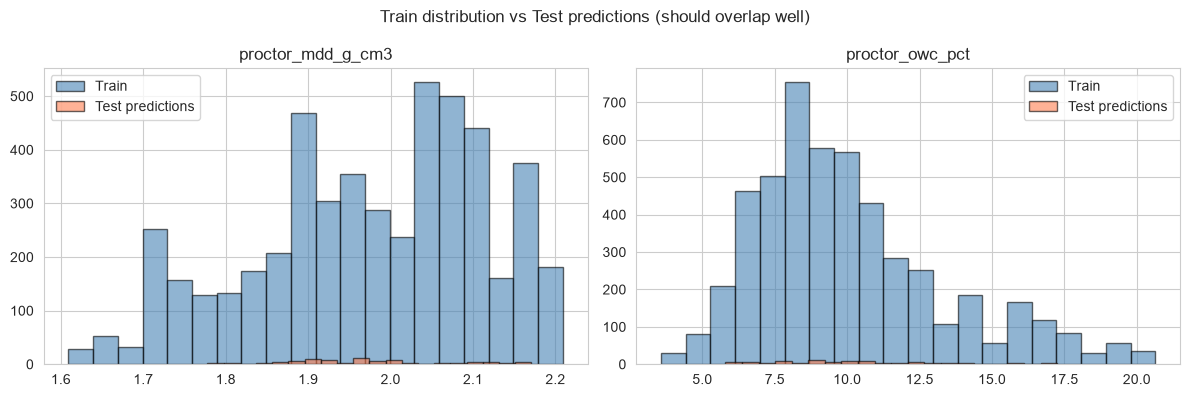


=== Final CV NMAE Summary ===
                        Model  CV NMAE
v1 tuned LGB (paper baseline)   0.2431
    v5 fixed blend (GBM+PINN)   0.3423
      v5 tuned XGB (v5 feats)   0.3426
    v5 Ridge stack (GBM+PINN)   0.3427
          v5 PINN (diversity)   0.3991


In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (train_y, pred_y, col) in zip(axes, [
    (y_mdd, pred_mdd_constrained, 'proctor_mdd_g_cm3'),
    (y_owc, pred_owc, 'proctor_owc_pct')
]):
    ax.hist(train_y, bins=20, alpha=0.6, label='Train', color='steelblue', edgecolor='k')
    ax.hist(pred_y,  bins=20, alpha=0.6, label='Test predictions', color='coral', edgecolor='k')
    ax.set_title(col)
    ax.legend()
plt.suptitle('Train distribution vs Test predictions (should overlap well)', fontsize=12)
plt.tight_layout()
plt.show()

print('\n=== Final CV NMAE Summary ===')
print(comparison.round(4).to_string(index=False))